# 05 — Baseline Models

Establish strong baselines **before** building complex DL models.
Everything needs to beat these to justify the complexity.

| Model | Features | Justification |
|-------|----------|---------------|
| OLS on MD | Last 3 VF MDs | Clinical standard |
| Random Forest | VF slopes + clinical | Strong ML baseline |
| Linear Regression | Clinical only | Minimal feature baseline |
| XGBoost | All tabular features | Tree-based SOTA baseline |

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

from src.utils.metrics import compute_regression_metrics, compute_clinical_metrics
from src.data.preprocessing import _ols_slope

PROC = Path("../data/processed")
SPLITS = Path("../data/splits")

np.random.seed(42)

## 1. Load Processed Data

In [2]:
# Synthetic data for demo (replace with real loaded data)
N = 200
np.random.seed(42)
true_rates = np.random.choice([-0.2, -0.5, -1.0, -2.0, -3.0], N, p=[0.3, 0.25, 0.2, 0.15, 0.1])

data = pl.DataFrame({
    "patient_id": [f"P{i:04d}" for i in range(N)],
    "md_rate_db_year": true_rates + np.random.normal(0, 0.2, N),
    "vfi_rate_pct_year": true_rates * 2.5 + np.random.normal(0, 0.5, N),
    "md_baseline": np.random.normal(-5, 4, N).clip(-28, 0),
    "vfi_baseline": np.random.normal(85, 15, N).clip(0, 100),
    "age_baseline": np.random.normal(63, 10, N).clip(40, 85),
    "iop_mean": np.random.normal(15, 4, N).clip(8, 30),
    "axial_length": np.random.normal(25, 1.5, N).clip(22, 30),
    "rnfl_mean": np.random.normal(70, 15, N).clip(30, 110),
    "cup_disc_ratio": np.random.uniform(0.3, 0.9, N),
    "n_visits": np.random.randint(3, 9, N),
    "follow_up_years": np.random.uniform(2, 7, N),
})

print(f"Dataset: {data.shape}")
print(data.head(3))

Dataset: (200, 12)
shape: (3, 12)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬──────────┬───────────┐
│ patient_i ┆ md_rate_d ┆ vfi_rate_ ┆ md_baseli ┆ … ┆ rnfl_mean ┆ cup_disc_ ┆ n_visits ┆ follow_up │
│ d         ┆ b_year    ┆ pct_year  ┆ ne        ┆   ┆ ---       ┆ ratio     ┆ ---      ┆ _years    │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ f64       ┆ ---       ┆ i64      ┆ ---       │
│ str       ┆ f64       ┆ f64       ┆ f64       ┆   ┆           ┆ f64       ┆          ┆ f64       │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪══════════╪═══════════╡
│ P0000     ┆ -0.636005 ┆ -0.82117  ┆ -0.328872 ┆ … ┆ 56.830261 ┆ 0.490168  ┆ 5        ┆ 4.483477  │
│ P0001     ┆ -2.953549 ┆ -7.579969 ┆ -3.982317 ┆ … ┆ 57.596795 ┆ 0.560758  ┆ 6        ┆ 3.42137   │
│ P0002     ┆ -0.941386 ┆ -2.509508 ┆ -3.649589 ┆ … ┆ 66.602817 ┆ 0.764328  ┆ 5        ┆ 2.669142  │
└───────────┴───────────┴───────────┴───────────┴───┴────

In [3]:
# Split into train/test
n_train = int(0.7 * N)
train_df = data[:n_train]
test_df  = data[n_train:]

feature_cols = ["md_baseline", "vfi_baseline", "age_baseline", "iop_mean",
                "axial_length", "rnfl_mean", "cup_disc_ratio", "n_visits", "follow_up_years"]

X_train = train_df[feature_cols].to_numpy()
y_md_train  = train_df["md_rate_db_year"].to_numpy()
y_vfi_train = train_df["vfi_rate_pct_year"].to_numpy()

X_test  = test_df[feature_cols].to_numpy()
y_md_test   = test_df["md_rate_db_year"].to_numpy()
y_vfi_test  = test_df["vfi_rate_pct_year"].to_numpy()

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (140, 9) | Test: (60, 9)


## 2. Baseline 1: Clinical Mean (Naive Baseline)

In [4]:
# Predict train mean for all test patients
naive_md  = np.full(len(y_md_test), y_md_train.mean())
naive_vfi = np.full(len(y_vfi_test), y_vfi_train.mean())

naive_metrics = {}
naive_metrics.update(compute_regression_metrics(naive_md, y_md_test, prefix="md"))
naive_metrics.update(compute_regression_metrics(naive_vfi, y_vfi_test, prefix="vfi"))
naive_metrics.update(compute_clinical_metrics(naive_md, y_md_test))

print("Naive Baseline (predict mean):")
for k, v in naive_metrics.items():
    print(f"  {k}: {v:.4f}")

Naive Baseline (predict mean):
  md_mae: 0.7067
  md_rmse: 0.8867
  md_r2: -0.0002
  md_bias: -0.0130
  vfi_mae: 1.8023
  vfi_rmse: 2.3256
  vfi_r2: -0.0032
  vfi_bias: 0.1311
  fast_progressor_sensitivity: 0.0000
  fast_progressor_specificity: 1.0000
  fast_progressor_ppv: 0.0000
  within_half_db_pct: 0.3500


## 3. Baseline 2: Ridge Regression

In [5]:
ridge_md = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=1.0))])
ridge_md.fit(X_train, y_md_train)
pred_md_ridge = ridge_md.predict(X_test)

ridge_vfi = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=1.0))])
ridge_vfi.fit(X_train, y_vfi_train)
pred_vfi_ridge = ridge_vfi.predict(X_test)

ridge_metrics = {}
ridge_metrics.update(compute_regression_metrics(pred_md_ridge, y_md_test, prefix="md"))
ridge_metrics.update(compute_regression_metrics(pred_vfi_ridge, y_vfi_test, prefix="vfi"))
ridge_metrics.update(compute_clinical_metrics(pred_md_ridge, y_md_test))

print("Ridge Regression:")
for k, v in ridge_metrics.items():
    print(f"  {k}: {v:.4f}")

Ridge Regression:
  md_mae: 0.7330
  md_rmse: 0.9126
  md_r2: -0.0595
  md_bias: -0.0001
  vfi_mae: 1.8764
  vfi_rmse: 2.4284
  vfi_r2: -0.0938
  vfi_bias: 0.1154
  fast_progressor_sensitivity: 0.3333
  fast_progressor_specificity: 0.5952
  fast_progressor_ppv: 0.2609
  within_half_db_pct: 0.4167


## 4. Baseline 3: Random Forest

In [6]:
rf_md = RandomForestRegressor(n_estimators=200, max_depth=6, min_samples_leaf=5, random_state=42)
rf_md.fit(X_train, y_md_train)
pred_md_rf = rf_md.predict(X_test)

rf_vfi = RandomForestRegressor(n_estimators=200, max_depth=6, min_samples_leaf=5, random_state=42)
rf_vfi.fit(X_train, y_vfi_train)
pred_vfi_rf = rf_vfi.predict(X_test)

rf_metrics = {}
rf_metrics.update(compute_regression_metrics(pred_md_rf, y_md_test, prefix="md"))
rf_metrics.update(compute_regression_metrics(pred_vfi_rf, y_vfi_test, prefix="vfi"))
rf_metrics.update(compute_clinical_metrics(pred_md_rf, y_md_test))

print("Random Forest:")
for k, v in rf_metrics.items():
    print(f"  {k}: {v:.4f}")

Random Forest:
  md_mae: 0.7353
  md_rmse: 0.9040
  md_r2: -0.0397
  md_bias: -0.0380
  vfi_mae: 1.8877
  vfi_rmse: 2.4123
  vfi_r2: -0.0794
  vfi_bias: 0.0309
  fast_progressor_sensitivity: 0.3889
  fast_progressor_specificity: 0.5714
  fast_progressor_ppv: 0.2800
  within_half_db_pct: 0.3833


## 5. Baseline 4: Gradient Boosting (XGBoost-style)

In [7]:
gb_md = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)
gb_md.fit(X_train, y_md_train)
pred_md_gb = gb_md.predict(X_test)

gb_vfi = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)
gb_vfi.fit(X_train, y_vfi_train)
pred_vfi_gb = gb_vfi.predict(X_test)

gb_metrics = {}
gb_metrics.update(compute_regression_metrics(pred_md_gb, y_md_test, prefix="md"))
gb_metrics.update(compute_regression_metrics(pred_vfi_gb, y_vfi_test, prefix="vfi"))
gb_metrics.update(compute_clinical_metrics(pred_md_gb, y_md_test))

print("Gradient Boosting:")
for k, v in gb_metrics.items():
    print(f"  {k}: {v:.4f}")

Gradient Boosting:
  md_mae: 0.8079
  md_rmse: 0.9876
  md_r2: -0.2410
  md_bias: -0.0791
  vfi_mae: 2.0042
  vfi_rmse: 2.5021
  vfi_r2: -0.1612
  vfi_bias: -0.0114
  fast_progressor_sensitivity: 0.5556
  fast_progressor_specificity: 0.5714
  fast_progressor_ppv: 0.3571
  within_half_db_pct: 0.3667


## 6. Comparison Summary

In [8]:
results = {
    "Naive": naive_metrics,
    "Ridge": ridge_metrics,
    "RandomForest": rf_metrics,
    "GradientBoosting": gb_metrics,
}

key_metrics = ["md_mae", "md_rmse", "md_r2", "vfi_mae", "fast_progressor_sensitivity"]

print(f"{'Model':<20}", end="")
for m in key_metrics:
    print(f"{m:<30}", end="")
print()
print("-" * (20 + 30 * len(key_metrics)))

for model_name, metrics in results.items():
    print(f"{model_name:<20}", end="")
    for m in key_metrics:
        val = metrics.get(m, float('nan'))
        print(f"{val:<30.4f}", end="")
    print()

Model               md_mae                        md_rmse                       md_r2                         vfi_mae                       fast_progressor_sensitivity   
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Naive               0.7067                        0.8867                        -0.0002                       1.8023                        0.0000                        
Ridge               0.7330                        0.9126                        -0.0595                       1.8764                        0.3333                        
RandomForest        0.7353                        0.9040                        -0.0397                       1.8877                        0.3889                        
GradientBoosting    0.8079                        0.9876                        -0.2410                       2.0042                        0.555

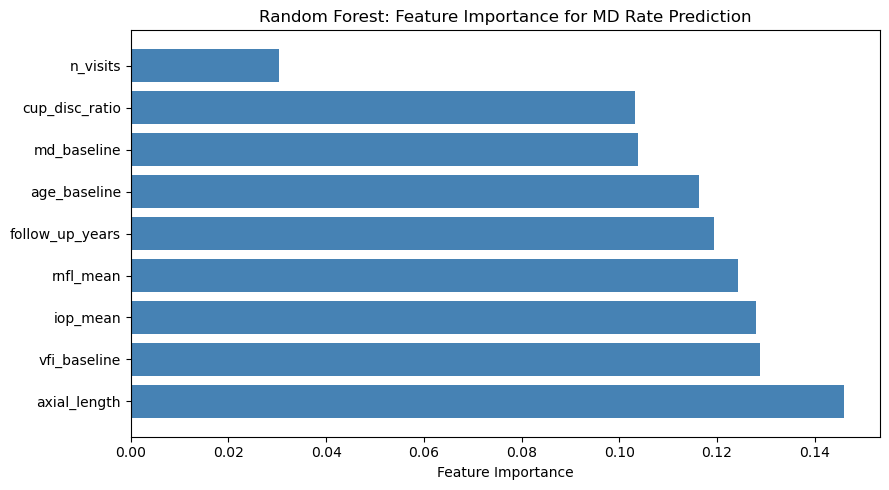

In [9]:
# Feature importance from RF
importances = rf_md.feature_importances_
order = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh([feature_cols[i] for i in order], importances[order], color="steelblue")
ax.set_xlabel("Feature Importance")
ax.set_title("Random Forest: Feature Importance for MD Rate Prediction")
plt.tight_layout()
plt.savefig("../reports/baseline_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Target to Beat

Our DL model (GLAM) must improve on the best baseline on ALL metrics.

In [10]:
best_md_mae = min(m["md_mae"] for m in results.values())
best_sensitivity = max(m["fast_progressor_sensitivity"] for m in results.values())

print("=" * 40)
print("TARGETS FOR GLAM DL MODEL")
print("=" * 40)
print(f"MD MAE to beat:             < {best_md_mae:.3f} dB/yr")
print(f"Fast progressor sensitivity:> {best_sensitivity:.3f}")
print()
print("→ Next: 06_backbone_exploration.ipynb")

TARGETS FOR GLAM DL MODEL
MD MAE to beat:             < 0.707 dB/yr
Fast progressor sensitivity:> 0.556

→ Next: 06_backbone_exploration.ipynb
